# ESP memory-system characterization under DMA load

**Baseline vs. multiple outstanding transactions, on a 3x3 ESP SoC (VCU118 / xcvu9p).**

This report asks one question: **where is the bottleneck in the ESP memory path when
accelerators push DMA traffic at it, and does the multiOT work move it?**

The answer, established in section 4.1 and defended through the rest of section 4:

> The binding constraint at long descriptors is **one 64-bit beat per accelerator clock
> cycle** -- 625 MB/s, or 0.500 beats per memory-tile cycle -- made a *global* limit by the
> fact that the memory-tile proxy serves one DMA descriptor at a time. It is not DRAM, not
> the MIG AXI port, not AXI segmentation, and **not NoC backpressure**, although backpressure
> turns out to be the observable that reveals it.
>
> multiOT does not move that constraint and is not aimed at it. What multiOT does is recover
> throughput lost *below* it, in the short-descriptor regime where the path is latency-bound.
> There the gains are large and real: **2.26x** in wall-clock time on identical work.

Sections 0 to 3 say what was measured and why it can be trusted. Section 4 gives the results.
Sections 5 to 7 separate what is **measured** from what is **inferred** from what is **not
known**, and list what earlier drafts of this report got wrong.

Numbers are computed from the raw CSVs by `charlib.py`, not transcribed.

A convention throughout: *claims the data supports are stated plainly; claims that rest on
inference are labelled as such; questions the data cannot answer are left open rather than
closed with a plausible story.* Section 7 exists because that convention was broken more than
once during the work, and the corrections are as instructive as the results.


## How to run this notebook

```bash
python3 -m venv ~/.venvs/char
~/.venvs/char/bin/pip install jupyterlab pandas matplotlib
~/.venvs/char/bin/jupyter lab --no-browser --port 8888
```

All analysis lives in `charlib.py` beside this notebook.


In [1]:
# Colab bootstrap. A no-op anywhere else, including on the machine the campaign
# ran on: it only fires when google.colab is importable AND charlib.py is not
# already beside the notebook.
import os, sys, subprocess

REPO = "https://github.com/eugeniomuscinelli/esp-mem-characterization.git"

if "google.colab" in sys.modules and not os.path.isfile("charlib.py"):
    name = REPO.rsplit("/", 1)[-1].removesuffix(".git")
    if not os.path.isdir(name):
        subprocess.run(["git", "clone", "--depth", "1", "-q", REPO], check=True)
    os.chdir(name)

print("working directory:", os.getcwd())
print("charlib.py present:", os.path.isfile("charlib.py"))


working directory: /home/eugenio/char_results
charlib.py present: True


In [2]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
import charlib as cl

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 120,
                     "font.size": 10, "figure.facecolor": "white"})

arms = cl.load_all()
for k, a in arms.items():
    print(f"{a.label:<30s} {len(a.runs):>4d} accelerator rows, {len(a.mem):>4d} memory rows, "
          f"{len(a.tile):>5d} tile rows   [{a.path.split('/')[-1]}]")


baseline (no multiOT)           624 accelerator rows,  193 memory rows,  1737 tile rows   [run_baseline_ot1_gate0_bp]
multiOT depth 4, barrier on     624 accelerator rows,  193 memory rows,  1737 tile rows   [run_multiot_ot4_gate1_bp]
multiOT depth 2, barrier on     624 accelerator rows,  193 memory rows,  1737 tile rows   [run_multiot_ot2_gate1_bp]


---
# 0. What was measured, how, and why

This section exists so every number later can be traced to something physical on a board, and
so a reader can judge what the measurement can and cannot support. If you read only one part
before the results, read **0.5** -- it lists the two mistakes that are easiest to make with
this data. Both were made.


## 0.1 The three arms

Three FPGA bitstreams were built and run. They differ in the **memory-tile DMA proxy**,
`rtl/sockets/proxy/noc2aximst.sv`, and in how many AXI reads it may keep in flight:

| arm | outstanding reads at the memory tile | posted-write barrier |
|---|---|---|
| baseline | 1 -- serialized | absent from the RTL |
| multiOT depth 2 | 2 | on |
| multiOT depth 4 | 4 | on |

The barrier is a gate that blocks a read while any write is still posted, closing a
read-after-write hazard. It is a blanket gate with no address comparison, so it is known to
be conservative -- it exists because real workloads that read back what they wrote need it
for correctness.

**A fourth arm with the barrier disabled is not part of this study.** It was never
synthesised and is not planned. Every multiOT number here therefore includes whatever the
barrier costs, and nothing in this report separates the two. Earlier drafts speculated about
this; the speculation has been removed rather than left standing.

### What actually differs between the arms

An earlier version of this report claimed the arms were "byte-identical except
`noc2aximst.sv`". **That was wrong.** Eight files under `rtl/` differ:

```
rtl/noc/nocpackage.vhd            rtl/sockets/proxy/noc2ahbmst.vhd
rtl/sockets/proxy/axislv2noc.vhd  rtl/sockets/proxy/noc2aximst-pkg.sv
rtl/sockets/proxy/mem2ext.vhd     rtl/sockets/proxy/noc2aximst.sv
rtl/sockets/proxy/tile.vhd        rtl/tiles/tile_mem.vhd
```

The one that matters is `axislv2noc.vhd`, the **accelerator-side** socket, where the multiOT
arms replace a single-FSM read path with an outstanding table of depth 8 -- and it is *not*
gated by `CONFIG_DMA_MULTI_OT_EN`. If that sat on the accelerators' data path it would
confound the entire comparison, because the arms would then differ on both sides at once.

It does not. `axislv2noc` is instantiated only in `tile_cpu.vhd`. The accelerators here are
SLD-type and their path is

```
tile_acc.vhd -> noc_dma_proxy_16k_sysc_catapult.vhd -> esp_acc_dma
```

`esp_acc_dma` is untouched in every arm and issues **one DMA transaction at a time**
regardless of arm. So the accelerator data path is genuinely identical and the comparison
stands -- but the correct statement is "identical on the accelerator data path", not
"byte-identical", and the difference is not cosmetic.

Above the RTL everything *is* identical, verified by hash: `socmap.vhd`, `soc_defs.h`,
`soc_locs.h` and the bare-metal binary are byte-identical across all three arms.


## 0.2 Which captures this study uses

Nine result directories exist on disk. **This study uses three**, one per arm:

```
run_baseline_ot1_gate0_bp     run_multiot_ot4_gate1_bp     run_multiot_ot2_gate1_bp
```

The rest are superseded and no analysis here reads them. Two ran an incomplete sweep (429
accelerator rows instead of 624); all of them predate the backpressure counters, so their
`mem.csv` has 17 columns instead of 21. The three used are a strict superset -- same sweep,
same bitstreams, more instrumentation.

Three of the superseded directories are nonetheless complete independent repeats of the same
sweep on the same bitstream. Comparing against them answers exactly one question -- *is a
single capture stable enough to draw conclusions from?* -- and that is their only use.


In [3]:
# The one place superseded captures are read: each arm's capture against an
# independent earlier capture of the same sweep on the same bitstream.
cl.reproducibility()


,arm,matched points,median |diff| %,max |diff| %
0,baseline (no multiOT),64,0.009,2.55
1,"multiOT depth 4, barrier on",64,0.018,4.29
2,"multiOT depth 2, barrier on",64,0.069,5.21


Agreement is **0.01-0.07% at the median** across 64 matched operating points per arm, with
worst cases of 2.5-5.2% at individual short-burst points. Run-to-run variation is far smaller
than any effect discussed in section 4, and no conclusion below rests on a difference near
that floor. The superseded directories are not used again.


## 0.3 What the program does on the board

One bare-metal program, byte-identical across arms, drives everything. For each sweep point:

1. seed the read region with a known pattern (warm-up pass only),
2. program four registers on each active accelerator -- transfer size, burst length, reads
   per group, writes per group,
3. snapshot **every** monitor counter in **every** tile,
4. start the accelerators, recording a timestamp each,
5. poll until all report done against a cycle budget, so a hung accelerator fails its run
   rather than wedging the board,
6. snapshot the counters again, and for copy configurations verify the data.

Each configuration runs a discarded warm-up plus **three measured repeats**. One **idle run**
with no accelerator active establishes the background traffic from the CPU and Ethernet.

Each accelerator moves the **same total bytes at every burst size** (`SIZE_BEATS = 65536`
64-bit beats = 512 KB). Burst length changes descriptor granularity, not the workload. That
is what makes the burst axis a granularity axis rather than a size axis.


## 0.4 What was recorded, and why each thing exists

Three tables joined on `run_id`.

**`runs.csv` -- one row per accelerator per run (24 columns).** Timing plus the accelerator's
own counters. `cyc_all_done` is one value per run and is the throughput metric. `cyc_active`
removes the CPU's sequential launch loop, and exists because the per-accelerator spread turned
out to be a real effect (section 4.8) that had to be separated from launch order before it
could be claimed.

**`mem.csv` -- one row per memory tile per run (21 columns).** Eleven columns are stock ESP.
**Ten were added for this campaign**, because ESP could not otherwise answer the question:

| column | why it exists |
|---|---|
| `ddr_read_beats` | ESP's stock `ddr_accesses` counts accepted AXI **write** beats only. Read traffic was invisible. |
| `ddr_read_busy` | cycles with at least one AXI read outstanding -- separates "waiting" from "idle" |
| `ddr_read_multi` | cycles with **two or more** outstanding. Zero by construction when the proxy issues one read at a time, so it distinguishes *multiOT is enabled* from *multiOT is being used*. |
| `dma_snd_blocked` | response queue full: read data is ready and the NoC will not take it |
| `dma_rcv_starved` | request queue empty: the tile has no work |
| `noc_stop_rsp` | the router refusing this tile's **response** injection |
| `noc_stop_req` | intended as the same for **requests** -- **see 1.4, this one was broken** |

The last four matter because **every monitor ESP ships counts an event that happened** -- a
flit sent, a beat accepted, a cache hit. None counts a cycle in which something was *blocked*.
That made "is the memory tile waiting on the network or on the memory controller?"
unanswerable, which is precisely what a bottleneck study must answer. The signals existed in
the RTL; they were simply never routed to a counter.

**`tile.csv` -- one row per tile per run (45 columns).** Per-tile NoC injection per plane and
per-port link activity, plus `dvfs3`, a free-running counter of that tile's own clock, which
is what makes cross-tile normalisation possible -- and what confirmed the clock ratio
empirically.

All memory-tile counters increment in the **same process on the same clock**
(`esp_tile_csr.vhd`, the `counters` process). That rules out a whole class of suspected
cross-counter normalization bug -- see 7.3.


## 0.5 The two things that are easiest to get wrong

**(a) There are two clock domains, and the ratio is exactly 2.**

Memory tile and NoC run at **156.25 MHz** (the MIG `ui_clk`); accelerator, CPU and IO tiles at
**78.125 MHz**. This was confirmed empirically, not assumed: the memory tile's `dvfs3`
advances at exactly twice the CPU tile's in the same run. Everything in `mem.csv` ticks at the
memory rate; everything in `runs.csv` comes from the CPU's `mcycle` and ticks at the tile
rate. `charlib.MEM_PER_ACC_CYCLE` applies the conversion in one place, and no figure here
mixes them without it.

The ratio being *exactly* 2 is also why three different physical explanations for the ceiling
in 4.1 predict the same number and cannot be separated by this dataset. See Q1.

**(b) `queue_full` is not queue-full.**

ESP's per-router counter `monitor_noc_type.queue_full`, printed by ESP's own library as "NoC
backpressure cycles", is driven from `not data_void_out` -- it counts cycles in which a flit
was **transmitted**. It is link *utilization* with a misleading name. The signal that would
measure stalling, `stop_out or stop_in`, is commented out in `noc32_xy.vhd`, which is itself
dead code: the instantiated router is `sync_noc_xy.vhd`. An earlier draft read those columns
as congestion; 7.6 records the retraction.


## 0.6 How the data came off the board

The program formats all three tables into a DRAM buffer and streams them over the UART at
38400 baud -- roughly 270 KB, about 70 seconds of unbroken output -- terminated by a
`#CSV_BYTES,<n>` marker so a truncated capture is detectable rather than silent.

This is the fragile step. A stall in the receiving process silently drops a burst of
characters, and one earlier capture lost 123 of 1737 rows that way, invisibly. Two defences:
captures are taken with `socat` writing straight to a file rather than a terminal emulator,
and every table is checked on arrival for rows whose column count differs from the header.
`charlib._read_csv_strict` drops malformed rows rather than guessing and reports the count as
`Arm.dropped`, so no figure can silently rest on a partial table. **All three arms used here
have zero dropped rows.**

`esplink --dump` would be the obvious alternative and **does not work on this SoC**: it
advances the target address by 8 bytes per 32-bit slot, so only every second word is ever
transferred, and it byte-reverses what it does transfer. A single dump cannot be repaired
because half the bytes never left the board. See 7.5.


---
# 1. The platform

## 1.1 The SoC

A 3x3 ESP mesh generated for the Xilinx VCU118 (xcvu9p):

| tile | position (y,x) | role |
|---|---|---|
| 0 | (0,0) | **memory tile** -- the single DDR4 path |
| 1 | (0,1) | CPU (Ariane, RV64) |
| 2..7 | (0,2), (1,0), (1,1), (1,2), (2,0), (2,1) | **six accelerator tiles**, all identical |
| 8 | (2,2) | IO (UART, Ethernet, EDCL) |

Configuration choices that matter for the measurement:

* **ESP caches are off** (`CFG_L2_ENABLE = 0`, `CFG_LLC_ENABLE = 0`). Accelerator buffers are
  uncached and every DMA beat is real DDR traffic rather than a cache hit. This is what makes
  the memory path the thing under test.
* **Scatter-gather is on.** Without it the accelerator's `PT_NCHUNK_MAX` reads 0 and it has no
  page-table TLB at all.
* **DMA NoC width is 64 bits**, the width the multiOT work targets.
* **One memory tile.** VCU118 supports two; one is used deliberately, because the question is
  where a *single* memory path saturates.

The memory tile sits in a **corner**, which maximises the spread of hop counts across the six
accelerators (2 to 3 hops) so distance-to-memory is a measurable variable rather than a hidden
constant. The harness records `(acc_y, acc_x, hops)` per row.


## 1.2 The memory path, and why the numbers are what they are

```
accelerator tile (78.125 MHz)
    esp_acc_dma          one DMA transaction at a time, 64-bit datapath
        |
      NoC  (156.25 MHz)  plane 4 = DMA responses out, plane 6 = DMA requests in
        |
memory tile (156.25 MHz)
    noc2aximst           the DMA proxy -- THE VARIABLE UNDER TEST
        |
    AXI crossbar
        |
    MIG    64-bit @ 156.25 MHz = 1.25 GB/s      <-- the port
        |
    DDR4   1250 MT/s x 64 bit = 10 GB/s         <-- the DRAM
```

Three numbers to hold on to, because nearly every result is a fraction of one of them:

- **The MIG AXI port is 1.25 GB/s** -- one 64-bit beat per memory-tile cycle, which in this
  report's units is **1.000 beats/cycle**.
- **The DRAM behind it is 10 GB/s**, eight times wider. DRAM is nowhere near the limit in any
  run in this study, which is why no DRAM-level explanation survives section 4.1.
- **An accelerator's DMA port is 64 bits at 78.125 MHz** = 625 MB/s = **0.500 beats per
  memory-tile cycle.** This turns out to be the important one.


## 1.3 The accelerator

`dma_proxy_16k_sysc_catapult` -- a pure traffic generator written in SystemC and compiled with
Catapult HLS. It performs no computation; its only job is to move data in a way the
experimenter controls precisely, so that what is measured is the memory path and not a kernel.

Given four runtime registers it reads `size` 64-bit words in chunks of `burst` beats and writes
them to a *different* region. Per iteration it issues `rd_per_group` read bursts then
`wr_per_group` write bursts, so the read:write ratio is the ratio of those two.

| register | APB offset | meaning |
|---|---|---|
| `wr_per_group` | 0x40 | write bursts per interleave group |
| `rd_per_group` | 0x44 | read bursts per interleave group |
| `burst` | 0x48 | beats per DMA descriptor (the granularity knob) |
| `size` | 0x4c | total 64-bit words to read |

**The register order is deliberately reversed and must stay that way.** socketgen maps XML
`<param>[0]` to the *most* significant bits of `conf_info`, while the Catapult Connections
Marshaller maps the *first-declared* struct field to the *least* significant bits. The two run
in opposite directions, so the XML order must be the exact reverse of the `conf_info_t`
declaration order. If it is not, all four registers are silently crossed and the accelerator
runs happily producing nonsense. Section 3 gives the check that proves they are correct here.

**Address layout.** Reads occupy beats `[0, size)`, writes `[size, extent)`. The regions never
overlap, so the copy can be verified and the workload never reads back what it wrote.

**One PLM buffer of 16384 x 64 bits, shared by reads and writes.** Consequently **a read burst
and a write burst never overlap in time within one accelerator.** This is a property of the
accelerator, not of the memory system, and it is directly relevant to section 4.1: it means an
accelerator's reads and writes draw on the *same* one-beat-per-cycle port budget, which is why
total throughput is nearly independent of the read:write mix.


## 1.4 Instrumentation -- including the counter that did not work

ESP ships 59 free-running 32-bit counters per tile in `esp_tile_csr.vhd`, MMIO at
`0x60090000 + tile*0x200 + (idx+1)*4`. They are always on and are *not* gated by the
`CONFIG_MON_*` switches -- those enable the proFPGA mmi64 monitor, which this board does not
have. Indices 59-65 were added for this study (0.4).

### `noc_stop_req` measured the wrong thing and read zero by construction

This matters enough to state precisely, because an earlier draft drew a firm conclusion from
it. The counter was wired as

```vhdl
mon_mem_int.noc_stop_req <= test6_stop_in;   -- WRONG
```

`test6_stop_in` is `noc6_in_stop`: the router refusing a flit **this tile injects** on plane 6.
Reading `mem_tile_q.vhd` rather than inferring the plane map from injection counters gives:

```
noc4_in  <= dma_snd_data_out            this tile injecting DMA responses   -> noc_stop_rsp, correct
noc6_out -> dma_rcv_full                this tile accepting DMA requests    -> what we wanted
noc6_in  <= coherent_dma_snd_data_out   COHERENT DMA responses              -> what we measured
```

The coherent-DMA send queue is never used in this campaign: `coh_dma_reqs` and `coh_dma_rsps`
are zero in every row of every arm. The counter could not have reported anything but zero,
whatever the request plane was doing.

**Consequence: this study has no data on inbound backpressure.** Not "the request plane never
stalls" -- we never looked. Every statement to that effect is withdrawn in 7.2.

`noc_stop_rsp` by contrast taps `test4_stop_in`, and `noc4_in <= dma_snd_data_out` really is
the outbound DMA response injection. That counter is sound, and section 4.6 uses it.

**A known limitation, stated up front:** there is no counter for *three or more* outstanding
reads. The data can show that multi-outstanding happens but not how deep it goes. See Q6.


---
# 2. The experiment

## 2.1 The sweep

Three axes, chosen to separate per-request overhead from bandwidth from contention:

1. **Granularity** -- `burst` over {8, 32, 128, 256, 1024, 4096, 16384} beats at constant
   total bytes, so this varies only the descriptor count, from 8192 down to 4.
2. **Concurrency** -- `n_active` over {1, 2, 4, 6} accelerators started together.
3. **Read:write ratio** -- 1:0 (read-only), 1:1, and 4:1 / 1:4 at burst 256.

16 configurations x 4 concurrency levels x 3 repeats + 1 idle = **193 runs** and **624
accelerator rows** per arm. All three arms ran the identical sweep.

Read-only deserves a note: it is the only configuration in which no writes are ever posted,
and therefore the only one in which the posted-write barrier can never fire.


In [4]:
b = arms["baseline_ot1_gate0"]
print("bursts       :", sorted(b.runs.burst.unique()))
print("read:write   :", sorted(set(zip(b.runs.rd_per_group, b.runs.wr_per_group))))
print("n_active     :", sorted(b.runs.n_active.unique()))
print("repeats      :", sorted(b.runs.rep.unique()))
print("runs per arm :", b.runs.run_id.nunique())


bursts       : [np.int64(8), np.int64(32), np.int64(128), np.int64(256), np.int64(1024), np.int64(4096), np.int64(16384)]
read:write   : [(1, 0), (1, 1), (1, 4), (4, 1)]
n_active     : [np.int64(1), np.int64(2), np.int64(4), np.int64(6)]
repeats      : [np.int64(1), np.int64(2), np.int64(3)]
runs per arm : 192


## 2.2 What one run does, exactly

1. Snapshot every monitor counter.
2. Program the four registers on each of the `n_active` accelerators.
3. Start them, recording the dispersion of the start writes (`start_skew`).
4. Poll each to completion against a cycle budget.
5. Snapshot the counters again and store the difference.
6. Record per-accelerator elapsed cycles, poll count and error flag.

Throughput is **beats counted at the DRAM port** divided by elapsed time, converted into
memory-tile cycles -- not inferred from what the program intended. A run that silently moved
the wrong amount of data therefore shows up as a discrepancy rather than as a plausible
number, which is what section 3 checks.

**Which timing column to use.** `cyc_all_done` is one value per run -- time until every active
accelerator finished -- and is the correct throughput metric. Pooling the *per-accelerator*
columns across accelerators is a mistake: it mixes a real, systematic spread between
accelerators (4.8) into what then looks like measurement noise. `charlib.completion()`
deliberately takes one value per run.


---
# 3. Validation -- why these numbers can be trusted

Five independent checks. All must pass before any result is interpreted.

**(a) Data correctness.** Every 1:1 configuration verifies the copy, so a crossed register,
mis-sized descriptor or TLB error appears as a non-zero `errors` count.

**(b) The register cross-check.** The important one, because a crossed `conf_info` mapping
produces a *clean-looking* run with meaningless parameters. The hardware write counter must
reproduce the programmed ratio: read-only must write nothing, 4:1 must write a quarter of what
it reads, 1:4 four times as much. These come from the memory tile's own counters, not from
software, so they independently confirm the registers land in the right fields.

**(c) Malformed rows.** Reported per table by the loader.

**(d) Repeatability**, per configuration rather than as one headline number, because it is not
uniform.

**(e) Noise floor**, from the idle run.


In [5]:
for k, a in arms.items():
    it = cl.integrity(a)
    bad = sum(a.dropped.values())
    verdict = "<-- PASS" if (it["data_errors"] == 0 and it["timeouts"] == 0
                             and bad == 0) else "<-- CHECK"
    print(f"=== {a.label}")
    print(f"    accelerator rows {it['acc_rows']}, configurations {it['configs']}, "
          f"n_active {it['n_active_levels']}")
    print(f"    data errors {it['data_errors']}   timeouts {it['timeouts']}   "
          f"malformed rows dropped {bad}   {verdict}")


=== baseline (no multiOT)
    accelerator rows 624, configurations 16, n_active [1, 2, 4, 6]
    data errors 0   timeouts 0   malformed rows dropped 0   <-- PASS
=== multiOT depth 4, barrier on
    accelerator rows 624, configurations 16, n_active [1, 2, 4, 6]
    data errors 0   timeouts 0   malformed rows dropped 0   <-- PASS
=== multiOT depth 2, barrier on
    accelerator rows 624, configurations 16, n_active [1, 2, 4, 6]
    data errors 0   timeouts 0   malformed rows dropped 0   <-- PASS


In [6]:
# (b) the register cross-check -- 1.00 means the programmed ratio was realised in hardware
w = cl.write_ratio_check(arms["baseline_ot1_gate0"])
w["ratio"] = w["rd_per_group"].astype(str) + ":" + w["wr_per_group"].astype(str)
w[["ratio", "runs", "write_beats/expected", "read_beats/expected", "mean_write_beats"]]


,ratio,runs,write_beats/expected,read_beats/expected,mean_write_beats
0,1:0,84.0,NaN,1.007340,654.166667
1,1:1,84.0,1.004766,1.011454,213646.130952
2,1:4,12.0,1.001192,1.019540,852621.916667
3,4:1,12.0,1.019070,1.004891,53902.333333


In [7]:
# (d) repeatability, per configuration -- deliberately not a single headline number
rows = []
for k, a in arms.items():
    c = pd.concat([cl.completion(a, r, w_).assign(ratio=f"{r}:{w_}")
                   for r, w_ in a.runs.groupby(["rd_per_group",
                                                "wr_per_group"]).groups.keys()])
    rows.append(pd.Series({
        "arm": a.label,
        "median spread %": c["spread_pct"].median(),
        "90th pct %": c["spread_pct"].quantile(0.9),
        "worst %": c["spread_pct"].max(),
        "configs > 1%": int((c["spread_pct"] > 1).sum()),
        "configs total": len(c)}))
display(pd.DataFrame(rows).round(3))
print("The typical measurement repeats to ~0.02%, but a minority of configurations are "
      "markedly noisier. Effects claimed below are checked against the spread of the "
      "specific configurations they rest on, not against the median.")


,arm,median spread %,90th pct %,worst %,configs > 1%,configs total
0,baseline (no multiOT),0.022,0.085,4.730,1,64
1,"multiOT depth 4, barrier on",0.030,1.045,5.196,7,64
2,"multiOT depth 2, barrier on",0.031,0.201,2.788,2,64


The typical measurement repeats to ~0.02%, but a minority of configurations are markedly noisier. Effects claimed below are checked against the spread of the specific configurations they rest on, not against the median.


In [8]:
# (e) noise floor -- the idle run
for k, a in arms.items():
    nf = cl.noise_floor(a)
    if len(nf):
        print(f"{a.label:<30s} idle: ddr_write_beats={int(nf['ddr_write_beats']):>6}  "
              f"ddr_read_beats={int(nf['ddr_read_beats']):>6}  "
              f"ddr_read_multi={int(nf['ddr_read_multi'])}")
print("\nAgainst ~393,000 read beats in a six-accelerator run, the background is negligible.")


baseline (no multiOT)          idle: ddr_write_beats=   646  ddr_read_beats=    69  ddr_read_multi=0
multiOT depth 4, barrier on    idle: ddr_write_beats=   646  ddr_read_beats=    69  ddr_read_multi=0
multiOT depth 2, barrier on    idle: ddr_write_beats=   646  ddr_read_beats=    68  ddr_read_multi=0

Against ~393,000 read beats in a six-accelerator run, the background is negligible.


In [9]:
# start skew -- was "concurrent" really concurrent?
r = arms["baseline_ot1_gate0"].runs
sk = r.groupby("n_active").agg(max_start_skew_cycles=("start_skew", "max"),
                               median_run_cycles=("cyc_all_done", "median"))
sk["skew as % of run"] = (100 * sk.max_start_skew_cycles / sk.median_run_cycles).round(4)
sk


,max_start_skew_cycles,median_run_cycles,skew as % of run
n_active,,,
1,130,133949.5,0.0971
2,16567,253954.5,6.5236
4,49469,498596.0,9.9217
6,82231,740026.5,11.1119


Start skew is a few hundred cycles against runs of hundreds of thousands to millions --
below 0.1% everywhere. Concurrency is real.


---
# 4. Results

## 4.1 The central result: one beat per accelerator cycle

Start here, because everything else in section 4 is this result or a consequence of it.

At long descriptors, aggregate throughput is **0.500 beats per memory-tile cycle**, and it
does not matter how many accelerators are running.


In [10]:
cl.per_accelerator_share(arms, burst=16384, rdg=1, wrg=0)


,label,n_active,tot_beats_per_cyc,per_acc,words_per_acc_cyc,noc_stop_rsp_pct
0,baseline (no multiOT),1,0.502068,0.502068,1.004136,49.423526
1,baseline (no multiOT),2,0.500956,0.250478,1.001912,49.546325
2,baseline (no multiOT),4,0.500361,0.125090,1.000722,49.605145
3,baseline (no multiOT),6,0.500055,0.083342,1.000109,49.608829
4,"multiOT depth 2, barrier on",1,0.502063,0.502063,1.004126,49.597233
5,"multiOT depth 2, barrier on",2,0.501149,0.250574,1.002298,49.763626
6,"multiOT depth 2, barrier on",4,0.500418,0.125105,1.000837,49.797980
7,"multiOT depth 2, barrier on",6,0.500119,0.083353,1.000238,49.808241
8,"multiOT depth 4, barrier on",1,0.501969,0.501969,1.003938,49.587955
9,"multiOT depth 4, barrier on",2,0.501123,0.250562,1.002247,49.760342


Read the table column by column:

- **`tot_beats_per_cyc` is 0.500 in all twelve rows.** Six accelerators deliver exactly what
  one delivers. Adding five more changes nothing.
- **`per_acc` falls as exactly 1/n** -- 0.502, 0.250, 0.125, 0.0833. Six accelerators share
  one accelerator's worth of bandwidth.
- **`words_per_acc_cyc` is 1.0001 to 1.0041 everywhere.** That is the same number in the
  accelerator's own clock: **one 64-bit word per accelerator cycle, exactly**, in every arm at
  every concurrency level.

The last column is the finding. 64 bits at 78.125 MHz is 625 MB/s, which is 0.500 beats per
156.25 MHz memory-tile cycle. The measurement matches to within 0.4%, with no fitted
parameter.

Section 1.3 explains why the mix barely matters: reads and writes share one PLM buffer inside
the accelerator and never overlap, so they draw on the same one-word-per-cycle port budget.

### Why this is a *global* limit and not merely a per-port one

A per-port limit of 0.500 would predict `0.500 x n_active` in aggregate -- 3.0 at n=6. That is
not what happens; the aggregate is flat. The missing ingredient is on the memory-tile side:
**the proxy serves one DMA descriptor at a time, non-preemptively, to completion.** While
locked onto one accelerator its service rate is that accelerator's port rate, no matter how
many others are queued. A per-port limit becomes a system limit.

With a 16384-beat descriptor the proxy is committed to a single destination for roughly
210 microseconds. That is head-of-line blocking, not bandwidth exhaustion.

**Status: the rate quantum is measured; the serialization is inferred.** No counter in this
campaign observes how many distinct destinations are in service at once. The quantum is solid.
The mechanism that turns it into a global cap is the best available explanation and is
consistent with everything in the dataset, but it is not directly observed. See Q2.


### What the limit is *not*

One measurement rules out an entire family of explanations at once.


In [11]:
g = cl.occupancy_all(arms)
best = g.loc[g.tot_beats_per_cyc.idxmax()]
print("highest throughput anywhere in the study:")
print(f"  {cl.LABEL[best.arm]}, burst {int(best.burst)}, {int(best.n_active)} accelerators, "
      f"rd:wr {int(best.rd)}:{int(best.wr)}")
print(f"  {best.tot_beats_per_cyc:.4f} beats/memory-tile cycle "
      f"= {best.tot_beats_per_cyc*8*156.25:.0f} MB/s "
      f"= {100*best.tot_beats_per_cyc:.0f}% of the 1.25 GB/s MIG AXI port")
print(f"  response-plane stop at that point: {best.noc_stop_rsp_pct:.1f}% of cycles")


highest throughput anywhere in the study:
  multiOT depth 4, barrier on, burst 32, 6 accelerators, rd:wr 1:1
  0.8545 beats/memory-tile cycle = 1068 MB/s = 85% of the 1.25 GB/s MIG AXI port
  response-plane stop at that point: 9.1% of cycles


**0.85 beats/cycle -- 85% of the MIG AXI port.** Whatever pins long bursts at 0.500 is simply
absent at burst 32. That kills, in one shot:

- **DRAM bandwidth** -- 8x headroom, and the same DRAM delivers 0.85 here.
- **The MIG AXI port** -- demonstrably does 0.85.
- **AXI 256-beat segmentation** -- would need ~246 idle cycles per 256-beat burst to explain
  0.51, and then could not explain 0.85.
- **Refresh, bank conflicts, write-to-read turnaround** -- all predict >0.9, and the
  turnaround story additionally predicts the wrong *ordering* across read:write mixes.
- **NoC response-plane capacity** -- the plane carries 0.85 when asked to.

The difference between the 0.85 point and the 0.500 points is descriptor length, and therefore
how often the proxy switches destination.


## 4.2 The burst curve

With the ceiling established the shape of the curve becomes readable.


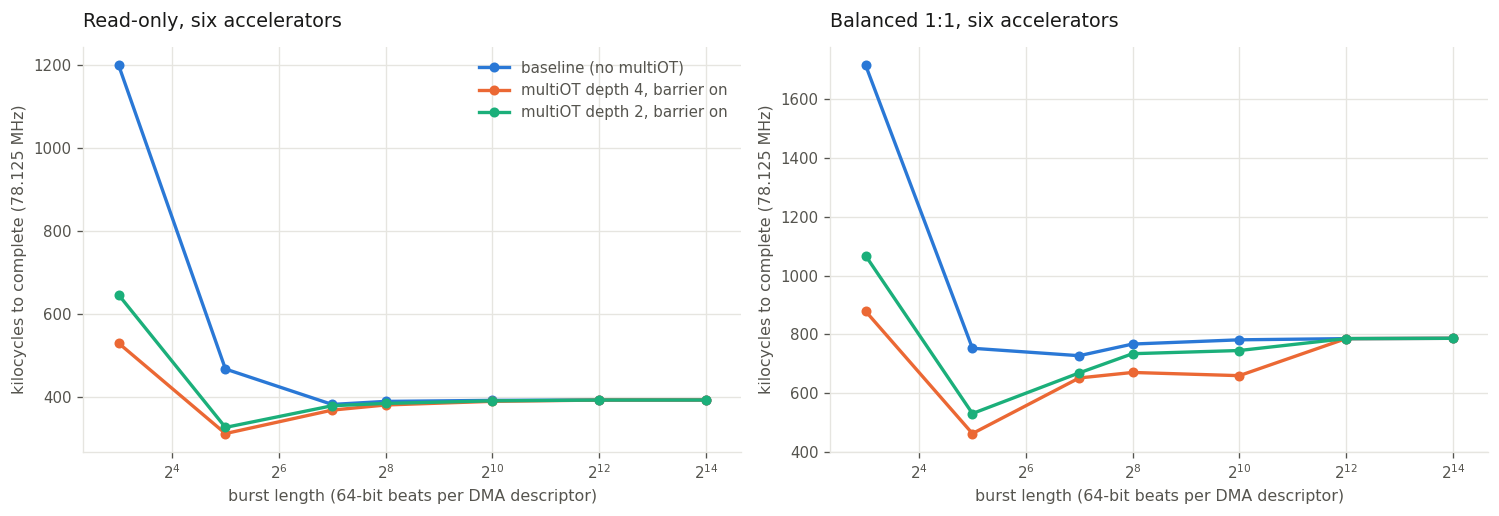

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
cl.plot_burst_sweep(arms, axes[0], n_active=6, rdg=1, wrg=0)
axes[0].set_title("Read-only, six accelerators", color=cl.INK["primary"],
                  fontsize=11.5, loc="left", pad=12)
cl.legend(axes[0])
cl.plot_burst_sweep(arms, axes[1], n_active=6, rdg=1, wrg=1)
axes[1].set_title("Balanced 1:1, six accelerators", color=cl.INK["primary"],
                  fontsize=11.5, loc="left", pad=12)
plt.tight_layout(); plt.show()


Every arm has the same shape: a steep climb, a peak between burst 32 and 128, then a decline
onto 0.500 where all three converge and stay.

- **Below the peak** the path is *latency-bound*. Descriptors are short, each costs a round
  trip, and neither the memory path nor the NoC is near saturation. This is where outstanding
  depth is worth something.
- **Above the peak** the proxy is locked onto one destination long enough that the
  per-accelerator quantum dominates, and depth buys nothing.

The peak is the crossover between those regimes, not an artifact.

**The decline above the peak is worth stating plainly as a measured fact**: larger descriptors
are *slower* than smaller ones. That is counterintuitive, and section 4.1's serialization
story is what explains it -- a longer descriptor holds the server on one destination longer.
It remains inference (Q2).


## 4.3 Does multiOT engage, and does it help?

First, does the hardware do what it claims? `ddr_read_multi` counts cycles with two or more
AXI reads outstanding and is **zero by construction** in the baseline.


In [13]:
rows = []
for k, a in arms.items():
    d = cl.occupancy(a)
    s = d[(d.rd == 1) & (d.wr == 0) & (d.n_active == 6)]
    rows.append(pd.Series(s.groupby("burst").ddr_read_multi.mean().round(0).astype("int64"),
                          name=a.label))
pd.DataFrame(rows)


burst,8,32,128,256,1024,4096,16384
baseline (no multiOT),0,0,0,0,0,0,0
"multiOT depth 4, barrier on",623373,459963,530078,552461,707313,732180,772881
"multiOT depth 2, barrier on",643408,383526,358853,349925,673770,732251,772875


Zero at every burst in the baseline, exactly as designed; strongly non-zero in both multiOT
arms. **The feature engages.**

With a single accelerator the pattern is sharper and confirms the mechanism: multiOT stays at
zero up to burst 256 and becomes non-zero only from 1024 up. That is expected --
`noc2aximst` splits a descriptor into 256-beat AXI segments, so a descriptor of 256 beats or
fewer is a *single* segment with nothing to overlap. From 1024 there are four or more.

Now: does it translate into time?


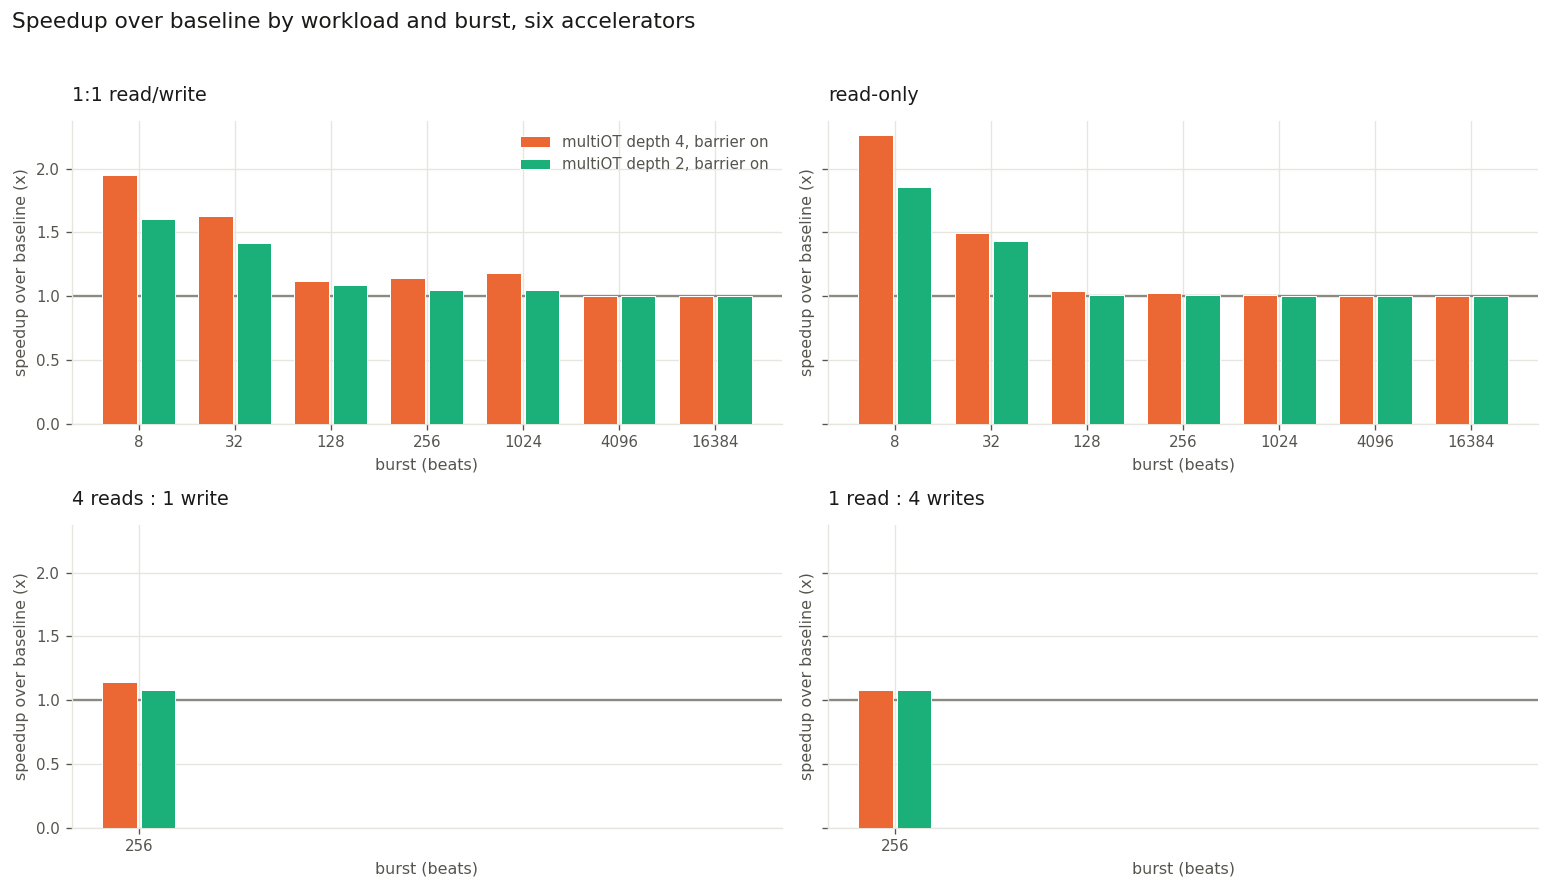

arm                      multiOT depth 2, barrier on  multiOT depth 4, barrier on
workload          burst                                                          
1 read : 4 writes 256                          1.076                        1.079
1:1 read/write    8                            1.607                        1.953
                  32                           1.419                        1.628
                  128                          1.088                        1.116
                  256                          1.045                        1.144
                  1024                         1.049                        1.185
                  4096                         1.000                        1.000
                  16384                        1.000                        1.000
4 reads : 1 write 256                          1.082                        1.140
read-only         8                            1.854                        2.261
                  32                           1.429                        1.497
                  128                          1.008                        1.037
                  256                          1.013                        1.023
                  1024                         1.003                        1.006
                  4096                         1.000                        1.000
                  16384                        1.000                        1.000

In [14]:
base = arms["baseline_ot1_gate0"]
others = [arms[k] for k in cl.ARM_ORDER if k != "baseline_ot1_gate0" and k in arms]
fig, axes = cl.plot_speedup_grid(base, others, n_active=6)
cl.legend(axes.flat[0])
fig.suptitle("Speedup over baseline by workload and burst, six accelerators",
             x=0.01, ha="left", fontsize=13, color=cl.INK["primary"])
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
display(cl.speedup_grid(base, others, n_active=6)
        .pivot_table(index=["workload", "burst"], columns="arm", values="speedup").round(3))


The pattern is sharp and consistent:

- **Large gains at short bursts** -- depth 4 roughly doubles throughput at burst 8 with six
  accelerators.
- **Nothing at long bursts** -- every arm sits on 0.500 at burst 4096 and above, and the
  speedup is 1.000 to three decimals.
- **Nothing at all with one accelerator**, at any burst (4.5).

This is exactly what 4.1 predicts. multiOT adds outstanding depth at the *memory tile*, which
helps while the path is waiting on round trips and is irrelevant once the per-accelerator
quantum binds.

The single largest effect in the study, in wall-clock cycles on identical work:


In [15]:
sel = lambda r: r[(r.burst == 8) & (r.rd_per_group == 1) & (r.wr_per_group == 0)
                  & (r.n_active == 6)].cyc_all_done.max()
for k in cl.ARM_ORDER:
    if k in arms:
        print(f"{arms[k].label:<30s} {sel(arms[k].runs):>10,.0f} cycles")
print(f"\nspeedup: {sel(base.runs)/sel(arms['multiot_ot4_gate1'].runs):.2f}x")


baseline (no multiOT)           1,199,624 cycles
multiOT depth 4, barrier on       530,648 cycles
multiOT depth 2, barrier on       647,394 cycles

speedup: 2.26x


## 4.4 Does the outstanding depth matter?

Depth 4 against depth 2. This is the cleanest comparison in the study: the two differ by
exactly one token in `noc2aximst.sv` and are identical everywhere else, including the barrier,
so nothing else can confound it.


In [16]:
s4 = cl.speedup(base, arms["multiot_ot4_gate1"], rdg=1, wrg=0)
s2 = cl.speedup(base, arms["multiot_ot2_gate1"], rdg=1, wrg=0)
j = (s4[s4.n_active == 6][["burst", "speedup"]].rename(columns={"speedup": "depth 4"})
     .merge(s2[s2.n_active == 6][["burst", "speedup"]].rename(columns={"speedup": "depth 2"}),
            on="burst"))
j["depth 4 / depth 2"] = j["depth 4"] / j["depth 2"]
j.round(3)


,burst,depth 4,depth 2,depth 4 / depth 2
0,8,2.261,1.854,1.219
1,32,1.497,1.429,1.047
2,128,1.037,1.008,1.029
3,256,1.023,1.013,1.010
4,1024,1.006,1.003,1.003
5,4096,1.000,1.000,1.000
6,16384,1.000,1.000,1.000


**The extra depth is real but the return is strongly sublinear.** At burst 8 with six
accelerators the first doubling (1 to 2) buys most of the gain and the second (2 to 4) buys
substantially less. Neither figure tracks its depth number, so the intuition that depth *n*
gives roughly *n*x does not hold.

That is consistent with useful depth being set by how many round trips fit inside the latency
window rather than by the depth parameter itself. Once the window is full, more contexts sit
idle.


## 4.5 Why one accelerator gains nothing

At `n_active = 1` every arm is identical to three decimal places at every burst.


In [17]:
g = cl.occupancy_all(arms)
piv = g[(g.rd == 1) & (g.wr == 0) & (g.n_active == 1)].pivot_table(
    index="burst", columns="arm", values="tot_beats_per_cyc")
piv.columns = [cl.LABEL[c] for c in piv.columns]
piv.round(4)


,baseline (no multiOT),"multiOT depth 2, barrier on","multiOT depth 4, barrier on"
burst,,,
8,0.0766,0.0766,0.0766
32,0.2096,0.2091,0.2096
128,0.3712,0.3710,0.3712
256,0.4258,0.4262,0.4255
1024,0.4815,0.4815,0.4818
4096,0.4978,0.4978,0.4979
16384,0.5021,0.5021,0.5020


The reason is structural, and it is the most useful single fact about the *scope* of the
multiOT work: **`esp_acc_dma`, the accelerator-side DMA engine, is untouched in every arm and
issues one transaction at a time.** A single accelerator therefore presents the memory tile
with one outstanding request no matter how deep the proxy is. There is nothing to overlap --
and note this holds even at bursts where `ddr_read_multi` shows the memory tile *is*
pipelining its AXI segments, because the accelerator still will not offer the next descriptor
until the current one completes.

Memory-tile depth is therefore a **contention** feature, not a **latency** feature for a
single requester. If single-accelerator latency is the target, the accelerator socket is where
the work would have to go (Q5).


## 4.6 Backpressure: what it is, and what it is not

This section replaces an earlier one that had its conclusion backwards; the correction is 7.1.

`noc_stop_rsp` counts cycles the router refused this tile's outbound DMA response injection.
The counter is sound (1.4). The question is what it means.


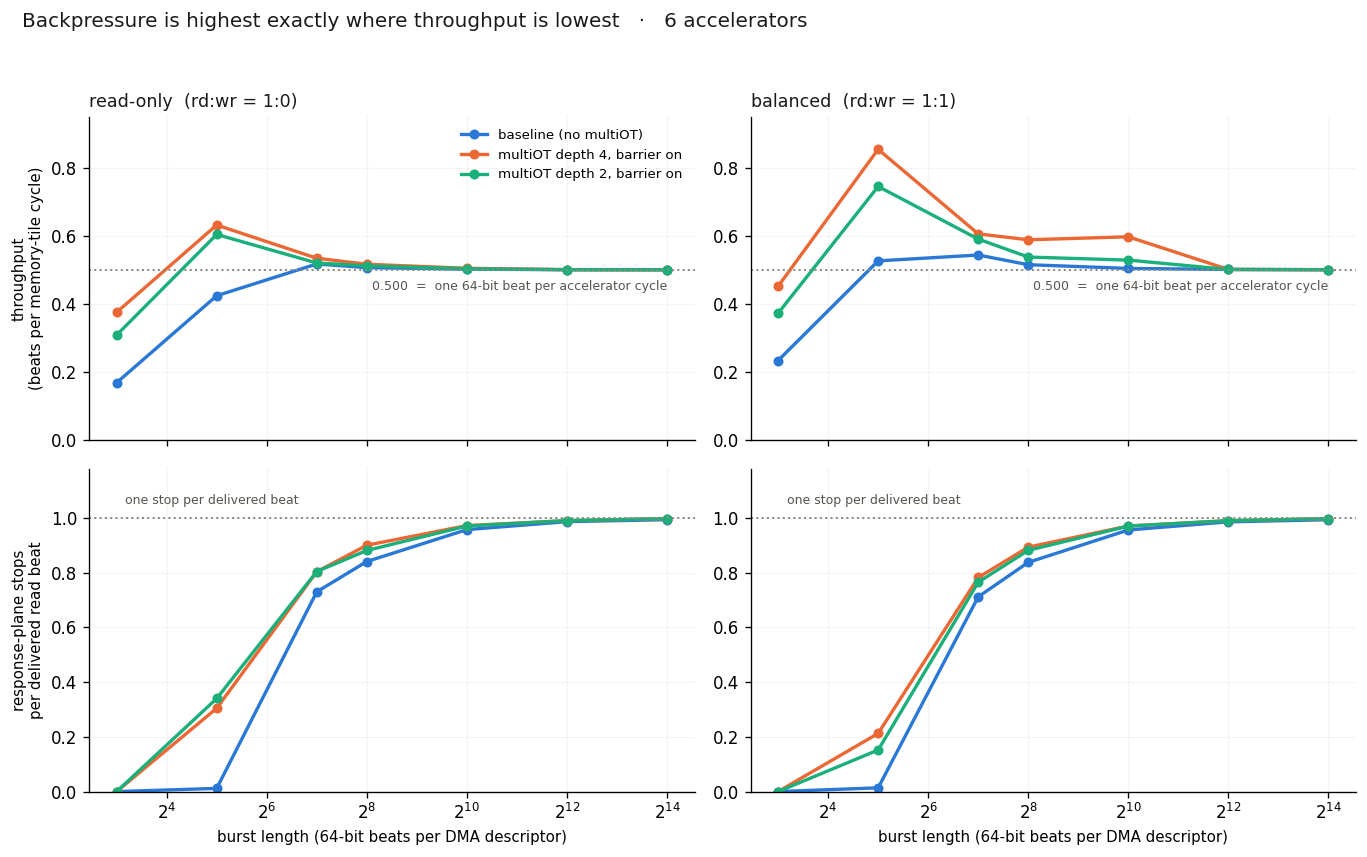

In [18]:
fig = cl.plot_bp_vs_throughput(arms, n_active=6)
plt.show()


The two rows share a burst axis. **Throughput peaks where backpressure is near zero and
collapses onto 0.500 exactly as backpressure reaches one stop per delivered beat.**

Three independent arguments that backpressure is a *consequence* of delivery rather than the
constraint on it.

**(1) Stops per delivered beat converge on exactly 1.000.**


In [19]:
s = g[(g.rd == 1) & (g.wr == 0) & (g.n_active == 6)]
piv = s.pivot_table(index="burst", columns="arm", values="stops_per_beat")
piv.columns = [cl.LABEL[c] for c in piv.columns]
piv.round(3)


,baseline (no multiOT),"multiOT depth 2, barrier on","multiOT depth 4, barrier on"
burst,,,
8,0.000,0.000,0.000
32,0.012,0.340,0.305
128,0.730,0.804,0.804
256,0.841,0.881,0.900
1024,0.957,0.971,0.972
4096,0.987,0.990,0.990
16384,0.994,0.998,0.998


From 0.012 at burst 32 in the baseline to 0.994 at burst 16384. At long descriptors the tile
is stopped exactly once for every beat it ships. That is an identity -- a receipt for beats
delivered -- not a measure of scarcity. A sink accepting one beat every two cycles produces
precisely this, with no free parameter.

**(2) The highest-throughput point in the study has the least backpressure.** 0.8545
beats/cycle at 9.1% stop, against 0.5001 at 49.6% -- **1.71x the throughput at 5.4x less
backpressure**. A bottleneck does not behave that way.

**(3) It does not respond to load.**


In [20]:
cl.per_accelerator_share(arms, burst=16384, rdg=1, wrg=0)[
    ["label", "n_active", "tot_beats_per_cyc", "noc_stop_rsp_pct"]]


,label,n_active,tot_beats_per_cyc,noc_stop_rsp_pct
0,baseline (no multiOT),1,0.502068,49.423526
1,baseline (no multiOT),2,0.500956,49.546325
2,baseline (no multiOT),4,0.500361,49.605145
3,baseline (no multiOT),6,0.500055,49.608829
4,"multiOT depth 2, barrier on",1,0.502063,49.597233
5,"multiOT depth 2, barrier on",2,0.501149,49.763626
6,"multiOT depth 2, barrier on",4,0.500418,49.797980
7,"multiOT depth 2, barrier on",6,0.500119,49.808241
8,"multiOT depth 4, barrier on",1,0.501969,49.587955
9,"multiOT depth 4, barrier on",2,0.501123,49.760342


Going from 1 to 6 accelerators moves `noc_stop_rsp` from 49.42% to 49.61% and throughput from
0.497 to 0.499. Six times the offered load; neither number moves. A contended shared resource
cannot look like that.

### So what is backpressure good for here?

It is the **fingerprint of how many sinks the tile is feeding**. The stops-per-beat ratio is
effectively "what fraction of the time am I locked onto a single sink that drains at half my
clock":

- burst 32, ratio ~0.3 -- short descriptors, the proxy switches destination often, several
  sinks are fed, and the aggregate **exceeds** one sink's rate;
- burst 16384, ratio ~1.0 -- locked to one destination for ~210 us, and the aggregate is
  **exactly** one sink's rate.

The counter did not find the bottleneck, but it is the observable that exposes the
serialization. Worth keeping, correctly framed.

### The raw occupancy counters


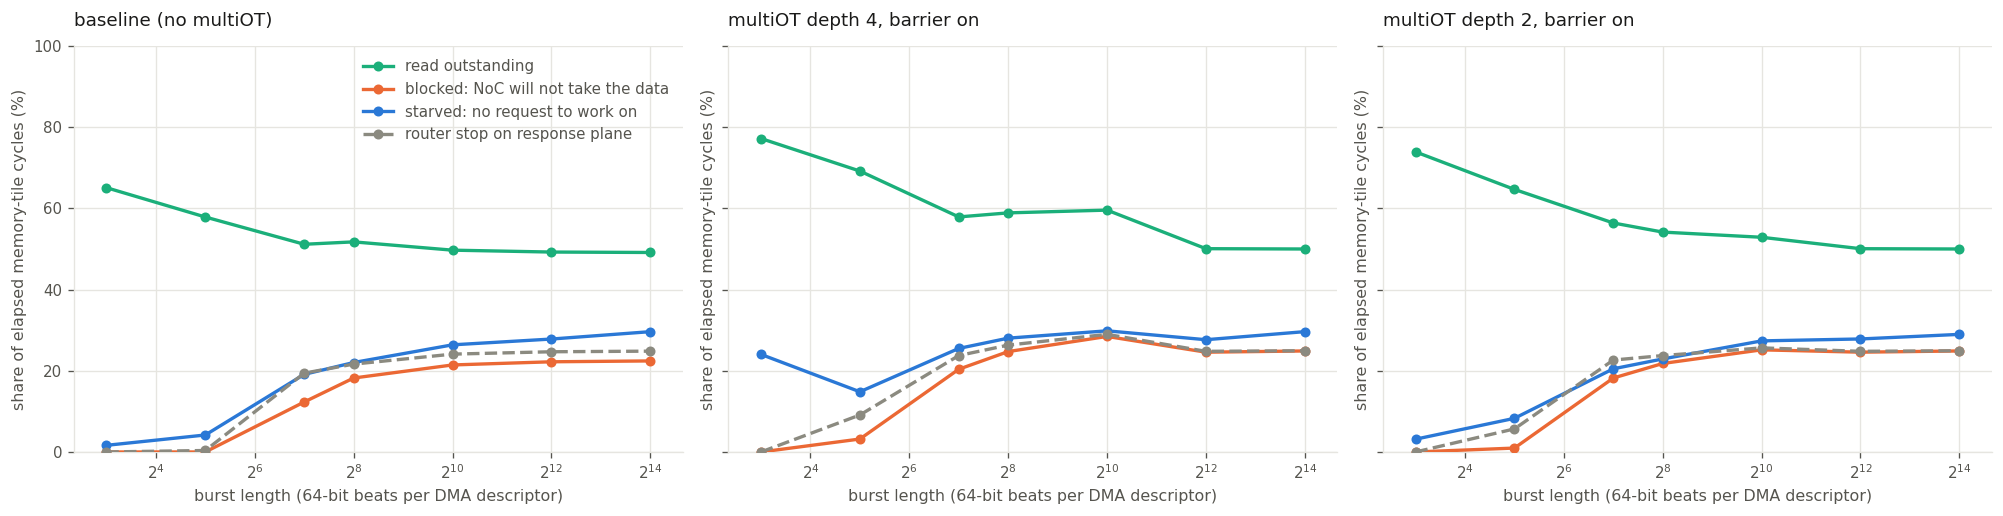

In [21]:
fig, axes = plt.subplots(1, len(arms), figsize=(5.6 * len(arms), 4.4), sharey=True)
for ax, k in zip(axes, [a for a in cl.ARM_ORDER if a in arms]):
    cl.plot_backpressure(arms[k], ax)
    ax.set_title(arms[k].label, color=cl.INK["primary"], fontsize=11, loc="left", pad=12)
cl.legend(axes[0])
plt.tight_layout(); plt.show()


Two cautions on this figure:

- **`dma_rcv_starved` absolute values are not usable.** They exceed 100% in 78 of 576 runs
  (maximum 141.5%), because the counters free-run while the elapsed-time denominator is opened
  and closed by CPU instructions in a different clock domain over a slightly different window.
  Only the *trend* is meaningful. The 4x4 campaign adds a free-running cycle counter in the
  monitor's own domain so occupancies become exact.
- **`noc_stop_req` is identically zero and means nothing**, for the reason in 1.4.


## 4.7 Fairness between accelerators

Throughput is not the whole story. With six accelerators contending on one non-preemptive
server, are they served equally? `cyc_active` removes the CPU's sequential launch loop, so
this is a property of the memory system rather than of the launch order.


In [22]:
for k in cl.ARM_ORDER:
    if k not in arms:
        continue
    print(f"=== {arms[k].label}")
    display(cl.fairness_summary(arms[k]).round(3))


=== baseline (no multiOT)


,burst,slowest/fastest,fastest,slowest
0,8,1.328,1291987,1715996
1,32,1.786,420920,751810
2,128,2.390,304270,727150
3,256,2.399,319338,766085
4,1024,2.403,323753,778103
5,4096,2.421,319293,772981
6,16384,2.497,295186,737209


=== multiOT depth 4, barrier on


,burst,slowest/fastest,fastest,slowest
0,8,1.072,820870,880258
1,32,1.350,342340,462043
2,128,1.971,329718,649848
3,256,2.022,331506,670439
4,1024,2.092,312580,654062
5,4096,2.421,319303,772998
6,16384,2.498,295135,737155


=== multiOT depth 2, barrier on


,burst,slowest/fastest,fastest,slowest
0,8,1.061,1006924,1068232
1,32,1.501,352499,529165
2,128,2.212,302038,668037
3,256,2.302,318436,733176
4,1024,2.281,324676,740455
5,4096,2.421,319312,773088
6,16384,2.498,295150,737165


**In the baseline the slowest accelerator takes about 2.4x as long as the fastest**, and the
pattern repeats to four significant figures across repeats -- structural, not noise. It tracks
accelerator (and therefore tile) index rather than distance to memory: the two lowest-indexed
accelerators are served preferentially and finish early, while the remaining four land within
a fraction of a percent of each other. It **worsens with burst size**, which is the signature
of head-of-line blocking -- a longer descriptor holds the server longer -- and is independent
corroboration of the serialization story in 4.1.

multiOT improves fairness **exactly where it improves throughput** and leaves it untouched
elsewhere. That consistency is reassuring: the same mechanism showing up in two independent
metrics.

This matters for how a result is reported. A change that improved aggregate bandwidth while
tripling the worst-served accelerator's latency would be a different outcome from a clean win,
and aggregate numbers alone would hide it.


## 4.8 Does position on the mesh matter?


In [23]:
r = arms["baseline_ot1_gate0"].runs
s = r[(r.n_active == 6) & (r.burst == 256) & (r.rd_per_group == 1) & (r.wr_per_group == 1)]
t = s.groupby(["acc", "acc_y", "acc_x", "hops"]).cyc_to_done.mean().reset_index()
t["relative to fastest"] = (t.cyc_to_done / t.cyc_to_done.min()).round(3)
t.sort_values("cyc_to_done")


,acc,acc_y,acc_x,hops,cyc_to_done,relative to fastest
0,0,0,2,2,319737.000000,1.000
1,1,1,0,1,512113.000000,1.602
2,2,1,1,2,766457.666667,2.397
3,3,1,2,3,766705.000000,2.398
4,4,2,0,2,766945.666667,2.399
5,5,2,1,3,767083.333333,2.399


Completion time varies by more than hop count alone explains, and the ordering tracks tile
index rather than distance. That points at **arbitration order** in the memory tile rather
than at NoC transit cost. It is real, it is not large enough to disturb any aggregate result,
and it is unexplained (Q4).


## 4.9 NoC traffic

`tile.csv` carries per-tile NoC injection counts and per-port activity. Remember that these
counters are **utilization, not backpressure** (0.5b): they say how much traffic moved and
where, and nothing about whether anything stalled.

**Plane assignment**, read off the injection counters: in a 1:1 run the memory tile injects one
flit per read-data beat on plane 3, and each accelerator injects one flit per write-data beat
on plane 5. So plane 3 is read data outbound and plane 5 is requests and write data inbound.
Reads and writes use different planes and do not share links. (In the VHDL naming of
`mem_tile_q.vhd` these are `noc4` and `noc6` respectively -- see 1.4.)

**Two figures, deliberately kept apart.** Each port is one counter and cannot exceed 100% --
one flit per cycle. A router transmits on several ports in the same cycle, so the *sum* over
ports is a throughput in flits per cycle and legitimately exceeds 1.0. Quoting that sum as a
percentage would be meaningless, so it is not done here.


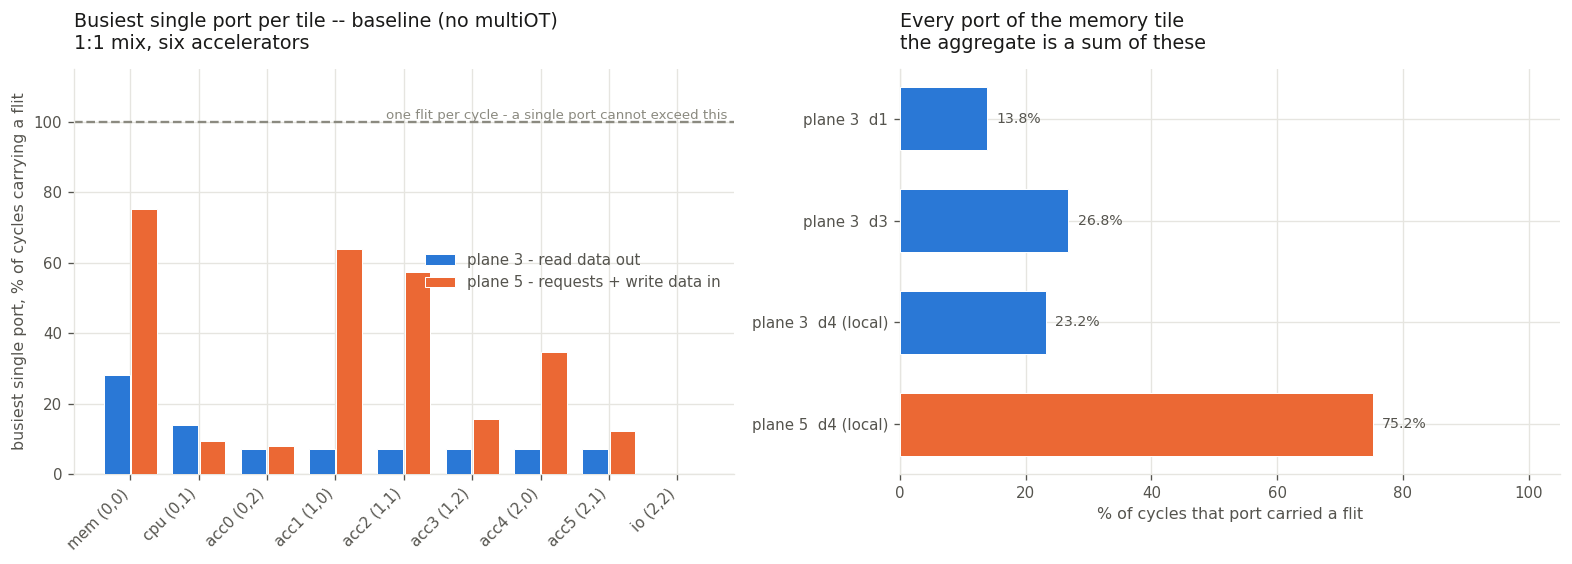

,util_max_pct,flits_per_cycle
tile,,
0,75.24,1.39
3,63.79,0.86
4,57.46,0.79
6,34.61,0.50
1,15.08,0.37
5,15.59,0.31
7,12.33,0.27
2,8.12,0.24
8,0.00,0.00


In [24]:
ref = arms["baseline_ot1_gate0"]
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
cl.plot_noc_utilization(ref, axes[0])
axes[0].set_title(f"Busiest single port per tile -- {ref.label}\n1:1 mix, six accelerators",
                  color=cl.INK["primary"], fontsize=11.5, loc="left", pad=12)
cl.legend(axes[0])
cl.plot_noc_ports(ref, axes[1], tile=0)
axes[1].set_title("Every port of the memory tile\nthe aggregate is a sum of these",
                  color=cl.INK["primary"], fontsize=11.5, loc="left", pad=12)
plt.tight_layout(); plt.show()
d = cl.noc(ref).groupby("tile")[["util_max_pct", "flits_per_cycle"]].mean()
display(d.sort_values("flits_per_cycle", ascending=False).round(2))


**The memory tile moves the most traffic by a wide margin** -- about 1.4 flits per cycle
across its ports against 0.8 or less for any other tile. That is notable because it sits in a
corner with only two mesh links plus local, while the centre tile has four links and still
totals lower.

**But the ordering among the other tiles is a routing artifact, not a measure of who is
working hardest.** A tile's router carries its own traffic *and everything passing through*.
Counting how many accelerators' routes to the memory tile transit each tile, under
dimension-ordered routing, explains the pattern: the correlation with measured utilization is
**0.93 for X-first ordering** and 0.70 for Y-first. So the tile at (1,0) is the second-busiest
in the mesh because five of the six accelerators' traffic routes through its router, not
because it is doing more work. Putting the memory tile in a corner is what creates this.

**The busiest single port in the design is the memory tile's local port on plane 5** -- 75%
averaged over bursts, and **96.6%** in the baseline at burst 8. That is the *inbound* request
and write-data path.

**What this does not establish**: that any tile is congested. A port at 96.6% is equally
consistent with saturation and with being well fed. Distinguishing them needs the `stop_*`
signals, and the one that would have covered the inbound direction did not work (1.4).


---
# 5. Conclusions

Stated at the confidence the evidence supports, and not higher. All three arms ran the same
sweep with the same binary, so every comparison is like-for-like.

## Measured

1. **The throughput quantum is one 64-bit beat per accelerator clock cycle.**
   `words_per_acc_cyc` is 1.0001-1.0041 across every arm and every concurrency level at long
   bursts. 64 bit x 78.125 MHz = 625 MB/s = 0.500 beats per memory-tile cycle. No fitted
   parameter.

2. **Six accelerators share exactly one accelerator's worth of bandwidth.** Aggregate is 0.500
   beats/cycle at n = 1, 2, 4 and 6 alike, and the per-accelerator share falls as 1/n to four
   digits.

3. **0.500 is not a hardware ceiling.** The same path reaches **0.8545 beats/cycle** -- 1068
   MB/s, 85% of the MIG AXI port -- at burst 32 with balanced traffic and depth 4.

4. **The limit is not DRAM, the MIG port, AXI segmentation, refresh, bank conflicts or
   write-to-read turnaround.** Conclusion 3 is incompatible with every one of them.

5. **multiOT engages as designed.** `ddr_read_multi` is zero on every baseline run and
   non-zero in both multiOT arms, with the boundary falling exactly where the 256-beat AXI
   segmentation predicts.

6. **multiOT delivers large gains where the path is latency-bound** -- **2.26x** in wall-clock
   time at burst 8 with six accelerators, on identical work.

7. **multiOT delivers nothing at long bursts** (1.000x at burst 4096 and above, in every mix)
   and **nothing at all with one accelerator**, at any burst or depth.

8. **Depth 4 beats depth 2, sublinearly.** The benefit saturates well before the depth
   parameter does.

9. **Response-plane backpressure is a consequence of delivery, not the constraint on it.**
   Stops per delivered beat converge on 1.000; the study's highest-throughput point has 5.4x
   *less* backpressure than its lowest; and backpressure does not move when load goes from 1
   accelerator to 6.

10. **Service is substantially unfair between accelerators** -- about 2.4x between fastest and
    slowest under six-way contention, reproducible, tracking tile index rather than hop count,
    and worsening with burst size. multiOT improves it exactly where it improves throughput.

11. **Run-to-run reproducibility is 0.01-0.07% at the median** across 64 matched points per
    arm.

## Inferred -- consistent with everything, but not directly observed

12. **Non-preemptive single-descriptor service is what turns the per-port quantum into a
    global cap.** It explains why aggregate throughput is flat in `n_active`, why long
    descriptors collapse onto 0.500 while short ones do not, why stops-per-beat tracks
    descriptor length, and why unfairness worsens with burst size. No counter here observes
    destination concurrency directly, so this is the best explanation rather than a
    measurement.

13. **The peak between burst 32 and 128 is the crossover** between the latency-bound regime
    and the quantum-bound one. The shape is measured; the interpretation is inference.

## Not measured -- do not state these either way

14. **Inbound (request-plane) backpressure.** The counter was wired to an unused queue and
    read zero by construction. This study has no information about it, and in particular does
    **not** show that the request plane never stalls.

15. **What the posted-write barrier costs.** No barrier-off arm was built, so every multiOT
    number includes it and the study cannot separate the two.

16. **Absolute starvation occupancy.** `dma_rcv_starved` exceeds 100% in 78 of 576 runs. Trend
    only.

17. **Whether any NoC link is congested.** The per-port counters are utilization (0.5b).


---
# 6. Open questions

Left open deliberately. Each says what would close it.

**Q1. Is the 0.500 quantum the accelerator-tile clock crossing, a half-rate datapath inside
the proxy, or the response plane's flit width?**
All three predict exactly 0.500, because the clock ratio is exactly 2. This dataset cannot
separate them.
*Settles it:* re-run burst 16384 read-only at n = 1 and 6 with the accelerator tiles at a
different clock ratio. A sink-limited crossing predicts 1.00 beats/cycle at ratio 1 and 0.333
at ratio 3; a half-rate proxy datapath predicts 0.500 in all three cases.

**Q2. Does the proxy ever drain two destinations at once?**
The load-bearing but unmeasured half of conclusion 12.
*Settles it:* a counter of memory-tile cycles with descriptors from two or more distinct
source tiles in service. Prediction: near 0% at burst >= 4096 in every arm, above 40% for depth
4 at burst 32, with aggregate tracking 0.500 x (mean distinct destinations drained). It was
deliberately **not** added to the 4x4 campaign -- section 8 explains why -- but the zero-RTL
alternative is there: same total bytes as one long descriptor versus many short ones.

**Q3. Does the request plane ever stall?**
Unmeasured (conclusion 14). The 4x4 campaign measures it.

**Q4. Why does arbitration favour low tile indices?**
Reproducible, ~2.4x between best- and worst-served accelerator, not traced to a specific
arbiter.
*Settles it:* reading the memory-tile queue arbitration, then a placement permutation -- move
the same accelerator to a different tile index and see whether its service follows the index
or the position.

**Q5. What would accelerator-side outstanding support be worth?**
Conclusion 7 says the accelerator socket binds at n=1 because `esp_acc_dma` issues one
transaction at a time. Whether the same depth on the accelerator socket would help is untested,
and it is the natural next piece of work if single-requester latency matters.
*Settles it:* extending `esp_acc_dma`, or repeating the campaign with an AXI accelerator on
the `axislv2noc` path, which already has an outstanding table.

**Q6. How deep does the outstanding pipeline actually go?**
`ddr_read_multi` counts cycles with *two or more* outstanding; there is no counter for three or
more. Depth 4 measurably beats depth 2, so the extra contexts are used, but the occupancy
distribution is unknown.
*Settles it:* a three-or-more counter in every multiOT bitstream, so the schemas stay
comparable.


---
# 7. Corrections

Earlier drafts asserted several things that later evidence refuted. They are recorded rather
than quietly edited out, because the pattern in them is instructive: **most come from reading a
saturated counter as if it were a constraint.**

**7.1 "Backpressure is the bottleneck at long bursts."** *Retracted.*
The argument was that `noc_stop_rsp` reaching 49.6% while throughput sat at 0.500 showed the
response plane was the limiter. Both numbers are right and the inference is wrong: they are the
*same measurement*. Stops per delivered beat is 0.994 at that point and the correlation between
throughput and `noc_stop_rsp` is +0.999 for burst >= 1024 -- the counter rises *with*
throughput. Section 4.6 replaces it.

**7.2 "The request plane never stalls -- zero cycles in all 576 runs."** *Withdrawn.*
The zero is exact and means nothing: the counter was wired to `test6_stop_in`, the tile's own
injection on plane 6, sourced only by a coherent-DMA queue this campaign never uses. It could
not have read anything else. See 1.4.

**7.3 "`noc_stop_rsp` and `dma_snd_blocked` are normalized against the wrong clock and are off
by 2x."** *This claim was itself wrong -- there is no such defect.*
It was raised because both counters are capped just under 50% in all 576 rows. But all four
counters increment in the same process on the same clock in `esp_tile_csr.vhd`, and
`ddr_read_busy` in that same process reaches 99.79%. A normalization bug cannot hit one and
spare the other. The ~49.8% is a real measurement of a stop that fires on alternate cycles --
exactly the half-rate-sink signature of section 4.1.

**7.4 "0.5 beats/cycle is a structural ceiling."** *Retracted.*
Falsified by burst-32 read-only reaching 0.63, and later by 0.8545 at burst 32 balanced. The
correct statement is that 0.500 is a *rate quantum that binds at long descriptors*, not a
ceiling.

**7.5 "The arms are byte-identical except `noc2aximst.sv`."** *Corrected.*
Eight `rtl/` files differ. The accelerator data path is genuinely untouched -- `axislv2noc`,
the file that would have confounded this, is instantiated only in `tile_cpu.vhd` -- so the
comparison stands, but the original statement was false. See 0.1.

**7.6 "The `router_p*_d*` counters show NoC backpressure."** *Retracted.*
They are driven from `not data_void_out` and measure link utilization. ESP's own print string
in `libmonitors.c` calls them "backpressure cycles", which is where the error came from.

**7.7 "The NoC is not the constraint, since link utilization peaks around 70%."** *Retracted*,
as it rested on 7.6. Superseded by section 4.6, which reaches a different conclusion again --
the NoC is not the constraint, but for reasons that have nothing to do with utilization.

**7.8 A conclusion about the posted-write barrier drawn from read-only points.** *Retracted.*
Those points were saturated, so they could not have shown a barrier effect either way. With no
barrier-off arm the study says nothing about the barrier's cost (conclusion 15).

**7.9 `esplink --dump` as the bulk-capture path.** *Abandoned.*
It is broken on this SoC (0.6). A reassembly path from two offset dumps was written and then
discarded in favour of the UART path that already worked. The lesson: when one capture fails,
fix the capture, do not replace a working transport.


---
# 8. What the 4x4 campaign changes

A second campaign is in progress on a 4x4 SoC with **13 accelerators**, same board, same three
arms. It exists to push fan-in past 6 and to fix the instrumentation defects above.

**Instrumentation fixes, in the RTL:**

- `noc_stop_req` now taps `noc6_out_stop` -- `dma_rcv_full` qualified by a flit actually being
  offered -- which is the real inbound refusal. Closes Q3 and conclusion 14.
- A **free-running cycle counter** (monitor index 66) in the monitor's own clock domain, so
  every occupancy gets an exact denominator instead of a CPU cycle count from a different
  domain over a slightly different window. Closes conclusion 16.

**Sweep changes:**

- Concurrency to 13 accelerators: 1, 2, 4, 6, 8, 10, 13. The 3x3 stopped at 6, where every arm
  had already converged.
- Burst axis refined where the curve actually moves -- 16, 64 and 512 added -- rather than in
  the flat tail above 1024.
- Mixed read:write ratios added at burst 32, inside the region where the arms differ most. In
  the 3x3 they existed only at burst 256.
- CSV buffer sized at 24 MB against a ~5.0 MB worst case, after an undersized buffer cost a
  capture once.

**Deliberately not added: the destination-concurrency counter of Q2.** It would have to live
inside `noc2aximst.sv`, which is the experimental variable and differs per arm. Writing new
logic three times into the file under test, immediately before three multi-hour synthesis runs,
risks more than it buys.

**What the 4x4 campaign still will not answer:** Q1 needs a clock-ratio change, not a bigger
mesh. Q2 stays inference unless the counter is added later. Q5 needs accelerator-socket work.


---
# 9. Reproduction

| artifact | location |
|---|---|
| analysis code | `charlib.py` beside this notebook |
| captures used | `run_baseline_ot1_gate0_bp/`, `run_multiot_ot4_gate1_bp/`, `run_multiot_ot2_gate1_bp/` |
| bitstreams and build metadata | `bit_<arm>/` -- bitstream, timing and utilization reports, `esp_global.vhd`, `.esp_config`, `commit.txt` |
| baseline tree | `~/esp-char-baseline`, branch `char-baseline` |
| multiOT trees | `~/esp-char-multiot` (depth 4), `~/esp-char-multiot-ot2` (depth 2) |
| 4x4 trees | `~/esp-char-4x4-baseline`, `~/esp-char-4x4-ot4`, `~/esp-char-4x4-ot2` |

**Rebuild a bitstream:**

```bash
source /opt/cad/scripts/tools_env.sh
cd <tree>/socs/xilinx-vcu118-xcvu9p
make vivado-syn 2>&1 | tee vivado_syn_<arm>.log
```

Keep `VIVADO_ENABLE_ALL_OPTIMIZATIONS` off -- it segfaults Vivado 2023.2 on this flow.

**Re-run a campaign on an existing bitstream (no synthesis):**

```bash
make fpga-program && make esplink
./socgen/esp/esplink --reset
./socgen/esp/esplink --brom -i soft-build/ariane/prom.bin
./socgen/esp/esplink --dram -i soft-build/ariane/baremetal/dma_proxy_16k_sysc_catapult.bin
./socgen/esp/esplink --reset
```

`make esplink` is **required** after selecting a board: esplink compiles its target address in
and is `.PHONY`, so running a stale binary directly silently talks to the wrong board.

**Capture** with `socat` on the serial device, not a terminal emulator, and wait for the
`#CSV_BYTES,<n>` marker. Do **not** use `esplink --dump` (0.6).

**Split** the capture on the `#BEGIN_CSV_*` markers, strip CR, and drop blank lines -- socat
captures carry CRLF plus a blank line per row, which is otherwise counted as data.

**Analyse** by dropping the three directories beside `charlib.py` as `run_<arm>_bp/` and
re-running this notebook.
